# Initialization

In [2]:
%load_ext autoreload
%autoreload 2

## Imports

In [3]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [4]:
import os
import itertools
from collections import OrderedDict
import math
from datetime import datetime
from pathlib import Path

import pandas as pd 
import wandb
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
from drvi.utils.metrics import DiscreteDisentanglementBenchmark


from drvi_notebooks.utils.data.data_configs import get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name
from drvi_notebooks.utils.misc import compare_objs_recursive

## Config

In [6]:
cwd = os.getcwd()
cwd

'/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public/drvi_notebooks/analysis'

In [7]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/ictstr01/groups/ml01/code/amirali.moinfar/projects/drvi_reproducibility_public')

In [8]:
(proj_dir / 'plots' / 'metrics_over_time').mkdir(parents=True, exist_ok=True)

In [9]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

# Run Data

## Retrieve

## Make history

In [10]:
wandb_address = 'kl_effect_DRVI_runs_drvi_4.7'

history_dict = {}
result_list = []

api = wandb.Api()
api.flush()

runs = api.runs(f"moinfar_proj/{wandb_address}")
for run in runs:
    val_history = run.history(samples=1000000, keys=[
        "epoch", 
        "validation_loss", "reconstruction_loss_validation", "elbo_validation", "mse_validation", "kl_local_validation",
    ]).drop(columns='_step')
    train_history = run.history(samples=1000000, keys=[
        "epoch", 
        "train_loss_epoch", "reconstruction_loss_train", "elbo_train", "mse_train", "kl_local_train",
    ]).drop(columns='_step')
    
    history_df = pd.merge(val_history, train_history, on='epoch')
    history_df['run'] = run.name
    history_dict[run.name] = history_df

    system_metrics = run.history(stream='systemMetrics').max()
    system_metrics.index = system_metrics.index.str.replace('\\.', '_')
    result_list.append({
        'name': run.name,
        'summary': run.summary._json_dict,
        'config': {k: v for k,v in run.config.items() if not k.startswith('_')},
        'system_metrics': system_metrics.to_dict(),
    })

runs_df = pd.json_normalize(result_list, sep='_')
runs_df = runs_df.query('(summary_epoch == config_params_max_epochs - 1)')
runs_df['dataset'] = runs_df['config_params_input_adata'].str.split("/").str[-1]

data_info_mapping = {
    'hlca_core_hvg.h5ad': {'col': 'ann_finest_level', 'name': 'HLCA'},
    'adata_hvg.h5ad': {'col': 'final_annotation', 'name': 'Immune'},
}
runs_df['annot_col'] = runs_df['dataset'].apply(lambda x: data_info_mapping[x]['col'])
runs_df['ds_name'] = runs_df['dataset'].apply(lambda x: data_info_mapping[x]['name'])

runs_df

,name,summary__runtime,summary__step,summary__timestamp,summary__wandb_runtime,summary_elbo_train,summary_elbo_validation,summary_epoch,summary_kl_global_train,summary_kl_global_validation,...,system_metrics_system_network_recv,system_metrics_system_cpu_106_cpu_percent,system_metrics_system_cpu_16_cpu_percent,system_metrics_system_gpu_process_0_memory,system_metrics_system_gpu_0_gpu,system_metrics_system_gpu_0_memory,system_metrics_system_gpu_process_0_gpu,dataset,annot_col,ds_name
0,drvi_20250728-205432-952853,20625.160980,165319,1.753749e+09,20684,589.599243,588.342896,399,0,0,...,8.349154e+07,100.00,3.90,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
1,drvi_20250728-205208-061438,22415.643864,165319,1.753751e+09,22475,721.694946,712.131226,399,0,0,...,1.177197e+08,3.37,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
2,drvi_20250728-173758-026611,20899.188022,165319,1.753738e+09,20979,630.795959,627.237244,399,0,0,...,1.455705e+08,100.00,55.17,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
3,drvi_20250728-173758-168989,14830.254336,165319,1.753732e+09,14913,694.877075,686.834412,399,0,0,...,1.031602e+08,100.00,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
4,drvi_20250728-173755-920191,19725.512794,165319,1.753737e+09,19797,684.683472,679.576294,399,0,0,...,1.738513e+08,100.00,100.00,22.93,49.00,22.93,49.00,hlca_core_hvg.h5ad,ann_finest_level,HLCA
5,drvi_20250728-173757-299556,23636.446729,165319,1.753741e+09,23724,590.212402,588.941833,399,0,0,...,1.807098e+08,100.00,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
6,drvi_20250728-173757-266095,14280.320828,165319,1.753731e+09,14349,582.819153,582.406128,399,0,0,...,1.147776e+08,100.00,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
7,drvi_20250728-173758-648761,11523.334839,165319,1.753729e+09,11617,582.829651,583.122742,399,0,0,...,9.366621e+07,2.06,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA
8,drvi_20250728-173755-961581,14113.467050,165319,1.753731e+09,14155,638.784119,629.404175,399,0,0,...,5.141907e+08,68.35,99.27,19.33,22.93,19.33,22.93,hlca_core_hvg.h5ad,ann_finest_level,HLCA
9,drvi_20250728-173756-363331,11719.363237,165319,1.753729e+09,11768,661.872192,656.989563,399,0,0,...,4.815188e+08,62.30,100.00,NaN,NaN,NaN,NaN,hlca_core_hvg.h5ad,ann_finest_level,HLCA


# Benchmarking disentanglement capabilities

In [11]:
version = DiscreteDisentanglementBenchmark.version
METRICS = ['SMI-disc', 'SPN', 'ASC']
AGGREGATION_METHODS = ['LMS', 'MSAS', 'MSGS']

benchmarks = {}
for i, row in runs_df.iterrows():
    run_name = row['name']
    col = row['annot_col']
    ds_name = row['ds_name']
    filename = logs_dir / "models" / run_name / f'DR_benchmark_on_{col}_{version}.pkl'
    
    if not filename.exists():
        embed = ad.read_h5ad(logs_dir / "models" / run_name / "latent.h5ad")
        discrete_target = embed.obs[col]
    
        print(f"Calculating disentanglement for {run_name} on {col}")
        # filename.touch()
        start_time = datetime.now()
        benchmark = DiscreteDisentanglementBenchmark(
            embed.X, discrete_target=discrete_target,
            metrics=METRICS, aggregation_methods=AGGREGATION_METHODS,
        )
        benchmark.evaluate()
        benchmark.save(filename)
        print(f"Time taken: {(datetime.now() - start_time).total_seconds():.2f} seconds")
    else:
        print(f"Disentanglement eval for {run_name} on {col} is already done. loading ...")

    benchmark = DiscreteDisentanglementBenchmark.load(filename, embed.X, discrete_target=discrete_target,
                                                      metrics=METRICS, aggregation_methods=AGGREGATION_METHODS)
    benchmarks[run_name] = benchmark.get_results()


Calculating disentanglement for drvi_20250728-205432-952853 on ann_finest_level
Time taken: 324.50 seconds
Calculating disentanglement for drvi_20250728-205208-061438 on ann_finest_level
Time taken: 325.84 seconds
Calculating disentanglement for drvi_20250728-173758-026611 on ann_finest_level
Time taken: 335.18 seconds
Calculating disentanglement for drvi_20250728-173758-168989 on ann_finest_level
Time taken: 333.52 seconds
Calculating disentanglement for drvi_20250728-173755-920191 on ann_finest_level
Time taken: 319.47 seconds
Calculating disentanglement for drvi_20250728-173757-299556 on ann_finest_level
Time taken: 314.77 seconds
Calculating disentanglement for drvi_20250728-173757-266095 on ann_finest_level
Time taken: 340.39 seconds
Calculating disentanglement for drvi_20250728-173758-648761 on ann_finest_level
Time taken: 339.15 seconds
Calculating disentanglement for drvi_20250728-173755-961581 on ann_finest_level
Time taken: 335.56 seconds
Calculating disentanglement for drvi_

In [12]:
benchmark_results = pd.DataFrame(benchmarks).T
benchmark_results

,LMS-SMI-disc,LMS-SPN,LMS-ASC,MSAS-SMI-disc,MSAS-SPN,MSAS-ASC,MSGS-SMI-disc,MSGS-SPN,MSGS-ASC
drvi_20250728-205432-952853,0.587739,0.458206,0.155859,0.704065,0.524697,0.159647,0.300793,0.315937,0.021069
drvi_20250728-205208-061438,0.521456,0.394321,0.155401,0.654804,0.484108,0.161443,0.283433,0.282190,0.017721
drvi_20250728-173758-026611,0.532104,0.417846,0.153597,0.683770,0.525253,0.160978,0.343100,0.356867,0.020026
drvi_20250728-173758-168989,0.290905,0.134855,0.129364,0.374287,0.164115,0.141374,0.107384,0.082538,0.015977
drvi_20250728-173755-920191,0.551385,0.440105,0.154521,0.682630,0.528453,0.161322,0.292366,0.324642,0.012560
drvi_20250728-173757-299556,0.539795,0.416871,0.153716,0.706740,0.534923,0.159260,0.345368,0.359045,0.020568
drvi_20250728-173757-266095,0.372972,0.194551,0.140524,0.504330,0.265649,0.151562,0.157343,0.134959,0.018125
drvi_20250728-173758-648761,0.405833,0.228267,0.144048,0.534262,0.308157,0.152646,0.162618,0.155599,0.018054
drvi_20250728-173755-961581,0.302375,0.156705,0.128767,0.409666,0.196037,0.146714,0.119585,0.102351,0.014771
drvi_20250728-173756-363331,0.286602,0.135570,0.128122,0.383999,0.174840,0.143380,0.106382,0.093097,0.016010


In [13]:
for col in benchmark_results.columns:
    runs_df[col] = benchmark_results[col].loc[runs_df['name']].values
runs_df

,name,summary__runtime,summary__step,summary__timestamp,summary__wandb_runtime,summary_elbo_train,summary_elbo_validation,summary_epoch,summary_kl_global_train,summary_kl_global_validation,...,ds_name,LMS-SMI-disc,LMS-SPN,LMS-ASC,MSAS-SMI-disc,MSAS-SPN,MSAS-ASC,MSGS-SMI-disc,MSGS-SPN,MSGS-ASC
0,drvi_20250728-205432-952853,20625.160980,165319,1.753749e+09,20684,589.599243,588.342896,399,0,0,...,HLCA,0.587739,0.458206,0.155859,0.704065,0.524697,0.159647,0.300793,0.315937,0.021069
1,drvi_20250728-205208-061438,22415.643864,165319,1.753751e+09,22475,721.694946,712.131226,399,0,0,...,HLCA,0.521456,0.394321,0.155401,0.654804,0.484108,0.161443,0.283433,0.282190,0.017721
2,drvi_20250728-173758-026611,20899.188022,165319,1.753738e+09,20979,630.795959,627.237244,399,0,0,...,HLCA,0.532104,0.417846,0.153597,0.683770,0.525253,0.160978,0.343100,0.356867,0.020026
3,drvi_20250728-173758-168989,14830.254336,165319,1.753732e+09,14913,694.877075,686.834412,399,0,0,...,HLCA,0.290905,0.134855,0.129364,0.374287,0.164115,0.141374,0.107384,0.082538,0.015977
4,drvi_20250728-173755-920191,19725.512794,165319,1.753737e+09,19797,684.683472,679.576294,399,0,0,...,HLCA,0.551385,0.440105,0.154521,0.682630,0.528453,0.161322,0.292366,0.324642,0.012560
5,drvi_20250728-173757-299556,23636.446729,165319,1.753741e+09,23724,590.212402,588.941833,399,0,0,...,HLCA,0.539795,0.416871,0.153716,0.706740,0.534923,0.159260,0.345368,0.359045,0.020568
6,drvi_20250728-173757-266095,14280.320828,165319,1.753731e+09,14349,582.819153,582.406128,399,0,0,...,HLCA,0.372972,0.194551,0.140524,0.504330,0.265649,0.151562,0.157343,0.134959,0.018125
7,drvi_20250728-173758-648761,11523.334839,165319,1.753729e+09,11617,582.829651,583.122742,399,0,0,...,HLCA,0.405833,0.228267,0.144048,0.534262,0.308157,0.152646,0.162618,0.155599,0.018054
8,drvi_20250728-173755-961581,14113.467050,165319,1.753731e+09,14155,638.784119,629.404175,399,0,0,...,HLCA,0.302375,0.156705,0.128767,0.409666,0.196037,0.146714,0.119585,0.102351,0.014771
9,drvi_20250728-173756-363331,11719.363237,165319,1.753729e+09,11768,661.872192,656.989563,399,0,0,...,HLCA,0.286602,0.135570,0.128122,0.383999,0.174840,0.143380,0.106382,0.093097,0.016010


HLCA


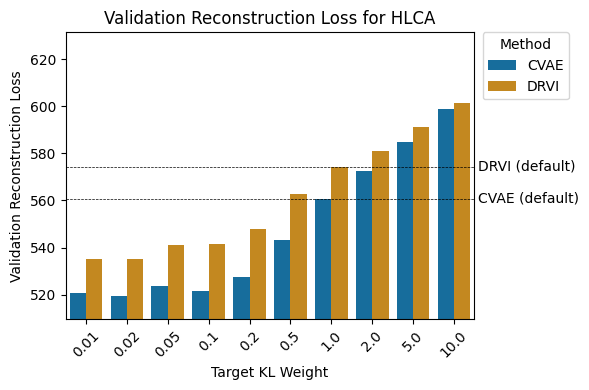

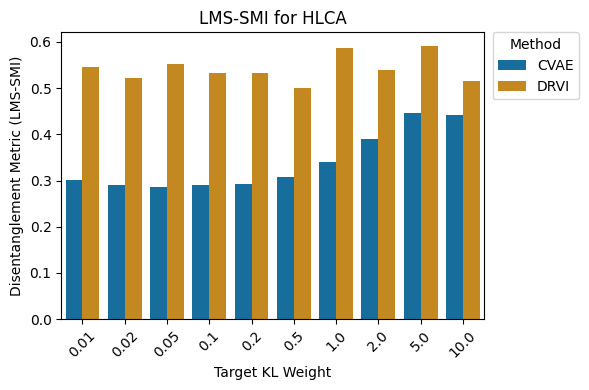

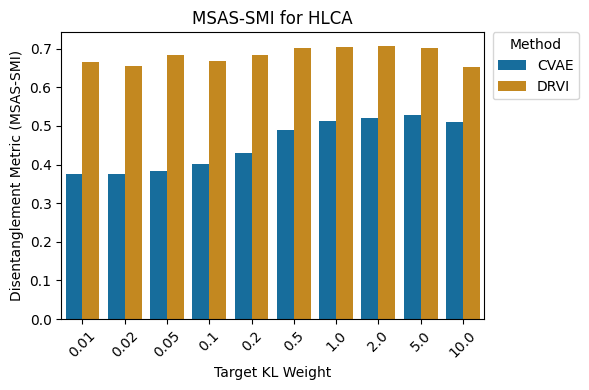

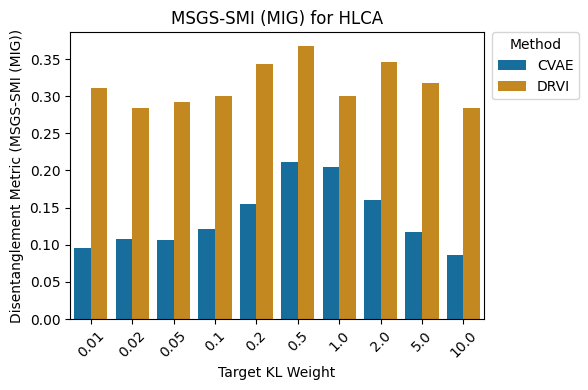

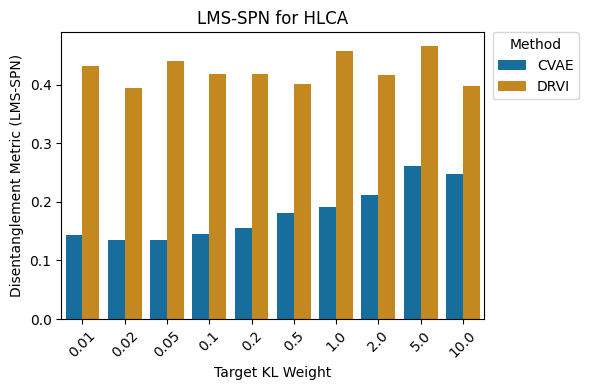

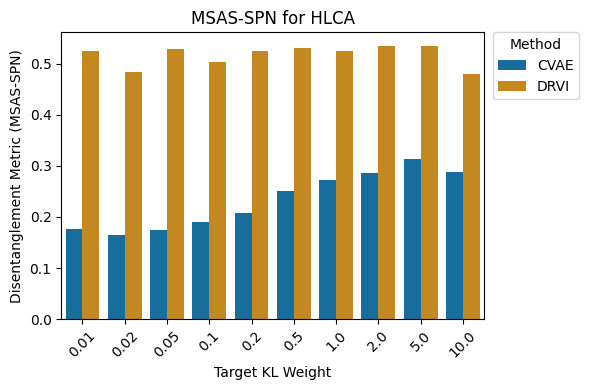

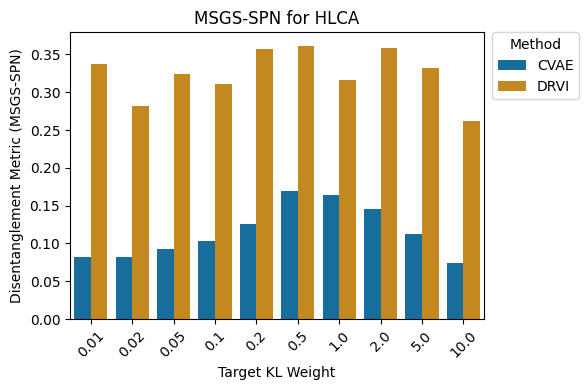

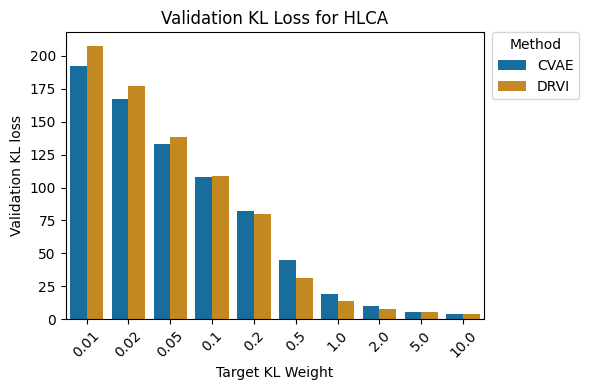

Immune


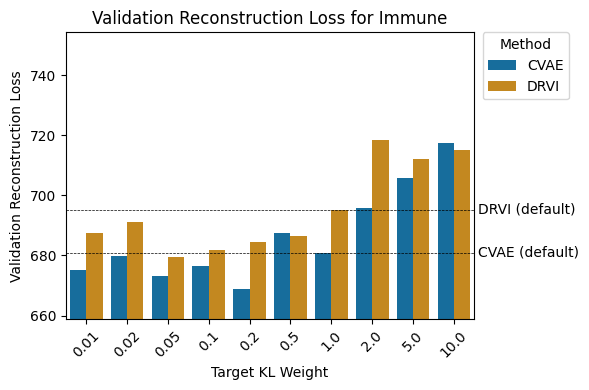

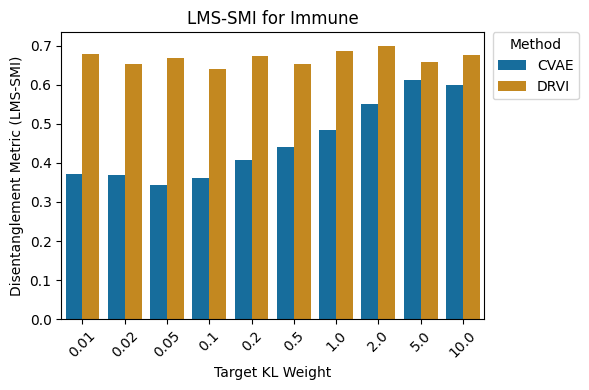

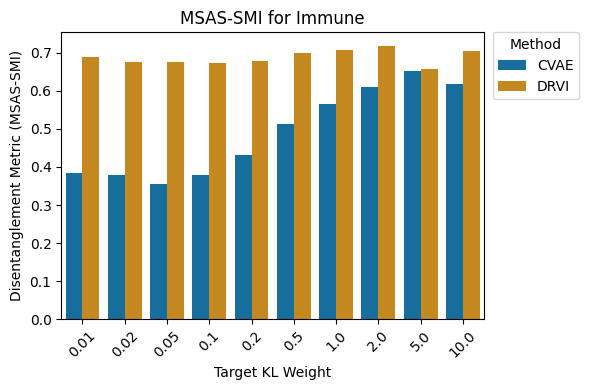

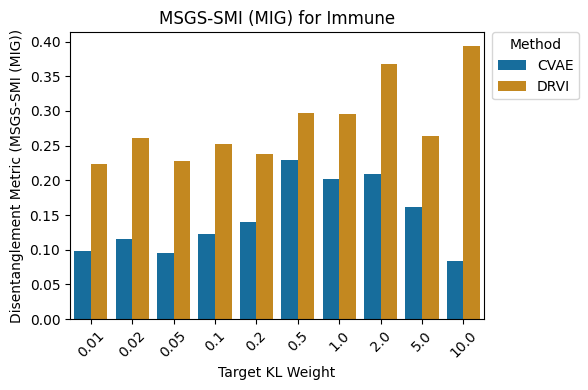

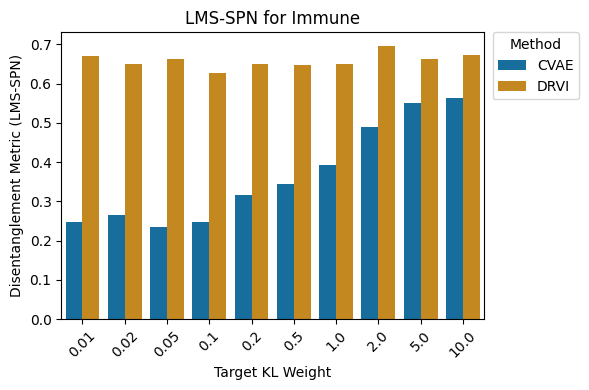

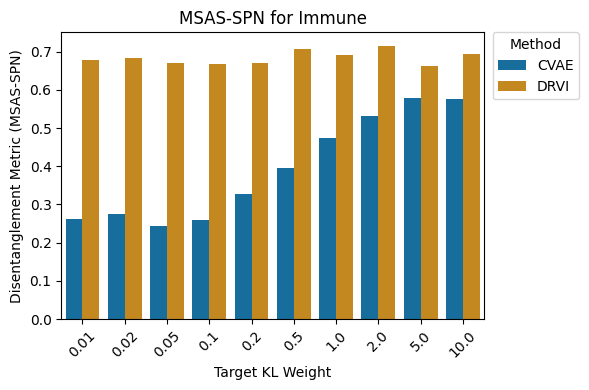

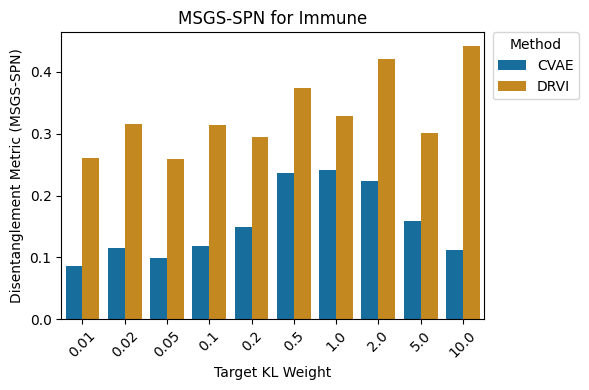

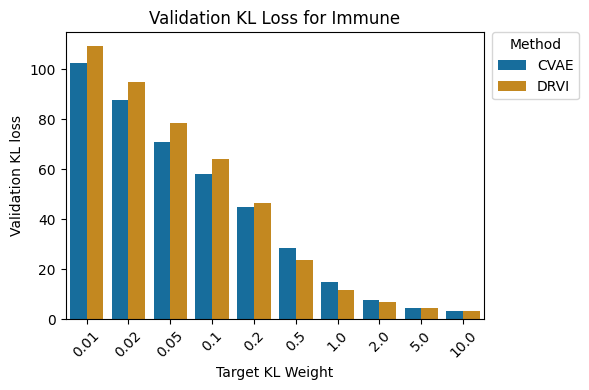

In [47]:
for ds_name in runs_df['ds_name'].unique():
    print(ds_name)
    plot_df = (
        runs_df[['config_params_target_kl', 'config_params_n_split_latent', 'summary_reconstruction_loss_validation', 'summary_kl_local_validation', 'ds_name',
                 *benchmark_results.columns.tolist()]]
        .query('ds_name == @ds_name')
        .assign(Method=lambda df: df['config_params_n_split_latent'].map({1: 'CVAE', 32: 'DRVI', 64: 'DRVI'}))
        .drop(columns='config_params_n_split_latent')
        .rename(columns={
            **{x: x.replace('SMI-disc', 'SMI').replace('MSGS-SMI', 'MSGS-SMI (MIG)') for x in benchmark_results.columns},
            'config_params_target_kl': 'Target-KL',
            'summary_reconstruction_loss_validation': 'Validation Reconstruction',
            'summary_kl_local_validation': 'Validation KL',
        })
    )

    # Ensure 'Target-KL' is sorted for consistent plotting
    plot_df = plot_df.sort_values(by=['Method', 'Target-KL'])

    # Barplot 1: Validation Reconstruction vs. Target-KL, stacked by Method
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=plot_df, x='Target-KL', y='Validation Reconstruction', hue='Method', palette='colorblind', ci=None)

    # Extract CVAE value for Target-KL == 1
    for method in ["CVAE", "DRVI"]:
        cvae_val = plot_df.query('Method == @method and `Target-KL` == 1')['Validation Reconstruction']
        if not cvae_val.empty:
            y_line = cvae_val.iloc[0]
            plt.axhline(y=y_line, color='black', linestyle='--', linewidth=.5)
            x_pos = len(plot_df['Target-KL'].unique()) - 0.4  # Adjust to appear on the far right
            plt.text(x=x_pos, y=y_line, s=f'{method} (default)', color='black', fontsize=10, va='center')

    # Set y-axis min to min + 10
    y_min = max(0, plot_df['Validation Reconstruction'].min() - 10)
    plt.ylim(bottom=y_min)

    plt.title(f'Validation Reconstruction Loss for {ds_name}')
    plt.xlabel('Target KL Weight')
    plt.ylabel('Validation Reconstruction Loss')
    plt.xticks(rotation=45)
    plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout()
    plt.savefig(proj_dir / 'plots' / 'metrics_over_time' / f'validation_reconstruction_barplot_{ds_name}.pdf')
    plt.show()
    plt.close()

    for metric in ['LMS-SMI', 'MSAS-SMI', 'MSGS-SMI (MIG)', 'LMS-SPN', 'MSAS-SPN', 'MSGS-SPN']:
        # Barplot 2: LMS-SMI vs. Target-KL, stacked by Method
        plt.figure(figsize=figsize)
        sns.barplot(data=plot_df, x='Target-KL', y=metric, hue='Method', palette='colorblind', ci=None)
        plt.title(f'{metric} for {ds_name}')
        plt.xlabel('Target KL Weight')
        plt.ylabel(f'Disentanglement Metric ({metric})')
        plt.xticks(rotation=45)
        plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
        plt.tight_layout()
        plt.savefig(proj_dir / 'plots' / 'metrics_over_time' / f'{metric}_barplot_{ds_name}.pdf')
        plt.show()
        plt.close()

    # Barplot 3: Validation KL vs. Target-KL, stacked by Method
    plt.figure(figsize=figsize)
    sns.barplot(data=plot_df, x='Target-KL', y='Validation KL', hue='Method', palette='colorblind', ci=None)
    plt.title(f'Validation KL Loss for {ds_name}')
    plt.xlabel('Target KL Weight')
    plt.ylabel('Validation KL loss')
    plt.xticks(rotation=45)
    plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(proj_dir / 'plots' / 'metrics_over_time' / f'validation_kl_barplot_{ds_name}.pdf')
    plt.show()
    plt.close()